In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="PizzeriaDB",
    user="postgres",
    password="9446" 
)

items = pd.read_sql_query('SELECT * FROM items', conn)
orders = pd.read_sql_query('SELECT * FROM orders', conn)
orders["created_at"] = pd.to_datetime(orders["created_at"]).copy()

C:\Users\user\AppData\Local\Temp\ipykernel_5324\700618391.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  items = pd.read_sql_query('SELECT * FROM items', conn)
C:\Users\user\AppData\Local\Temp\ipykernel_5324\700618391.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql_query('SELECT * FROM orders', conn)
C:\Users\user\AppData\Local\Temp\ipykernel_5324\700618391.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders["created_at"] = pd.to_datetime(orders["created_at"]).copy()


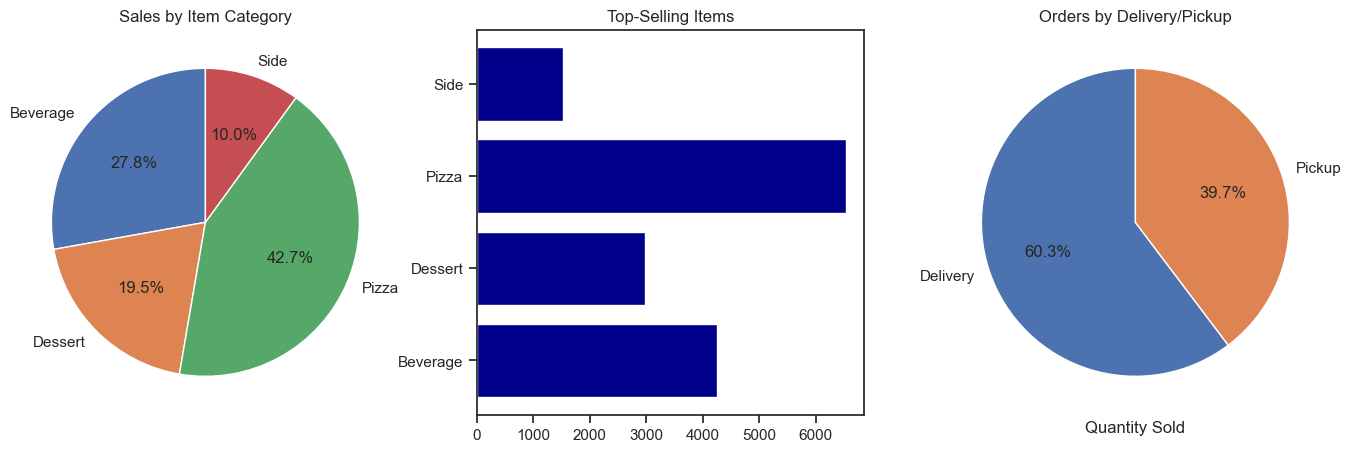

In [89]:
# Pie chart of Sales by Item Category
#Bar chart of Top-Selling Items
#Orders by delivery/pickup 

fig, ax=plt.subplots(1, 3, figsize=(17, 5))

merged = orders.merge(items, on='item_id')
sizes = merged.groupby('item_category')['quantity'].sum()
labels = sizes.index
sizes = sizes.values

ax[0].pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart of Sales by Item Category")
ax[0].set_title("Sales by Item Category")


sns.set_theme(style="ticks")
items_sold=merged.groupby('item_category')['quantity']
ax[1].barh(items_sold.sum().index, items_sold.sum().values, color='darkblue')
plt.xlabel("Quantity Sold")
plt.ylabel("")
ax[1].set_title("Top-Selling Items")

orders["delivery"] = orders["delivery"].replace({"0": "Pickup", "1": "Delivery"}) 
deliveries = orders["delivery"].value_counts() 
labels = deliveries.index 
sizes = deliveries.values 
ax[2].pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90) 
ax[2].set_title("Orders by Delivery/Pickup") 


plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_5324\764109524.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


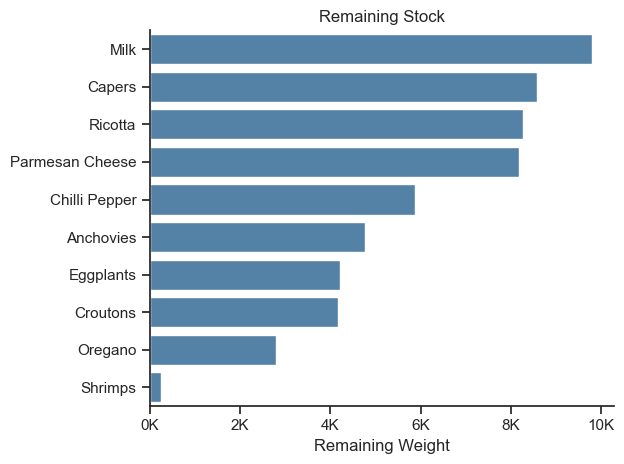

In [51]:
df = pd.read_sql_query("""
SELECT 
    s2.ing_name,
    s2.ordered_weight,
    (ing_weight * inv.quantity) AS total_inv_weight,
    (ing_weight * inv.quantity) - s2.ordered_weight AS remaining_weight
FROM (
    SELECT  
        ing_id,
        ing_name,
        sum(ordered_weight) as ordered_weight
    FROM stock1
    GROUP BY ing_id, ing_name
) as s2
LEFT JOIN inventory inv ON s2.ing_name = inv.ing_name
LEFT JOIN ingredients ing ON s2.ing_id = ing.ing_id;
""", conn)

df = df.sort_values("remaining_weight").head(10)

ax=sns.barplot(data=df, x="remaining_weight", y="ing_name", color="steelblue")
plt.title("Remaining Stock")
plt.xlabel("Remaining Weight")
plt.ylabel("")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_5324\475250233.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


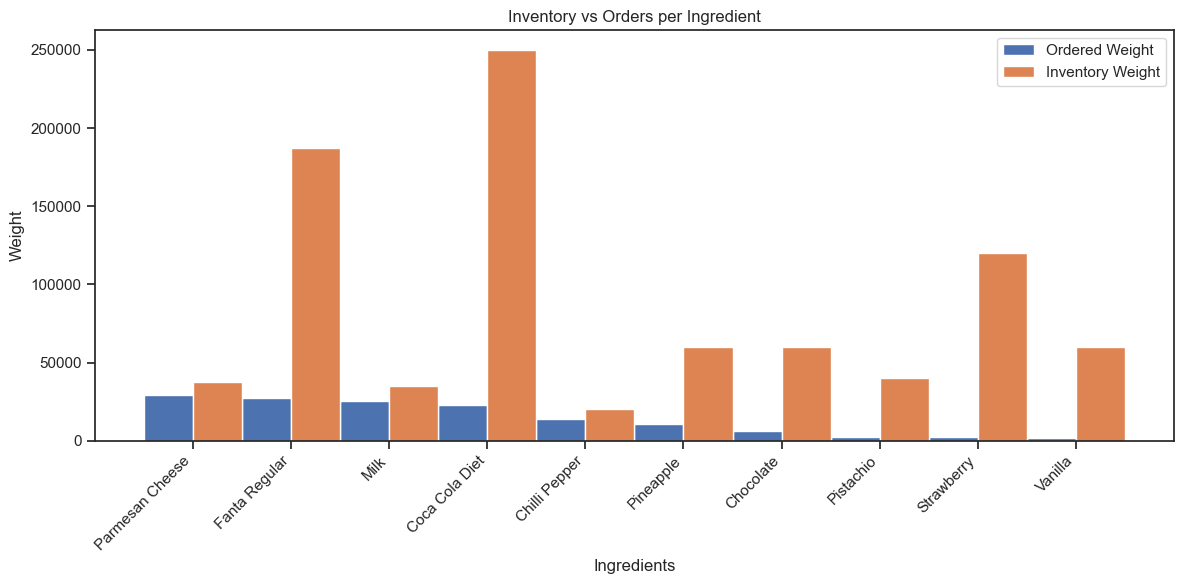

In [25]:
df = pd.read_sql_query("""
SELECT 
    s2.ing_name,
    s2.ordered_weight,
    (ing_weight * inv.quantity) AS total_inv_weight,
    (ing_weight * inv.quantity) - s2.ordered_weight AS remaining_weight
FROM (
    SELECT  
        ing_id,
        ing_name,
        sum(ordered_weight) as ordered_weight
    FROM stock1
    GROUP BY ing_id, ing_name
) as s2
LEFT JOIN inventory inv ON s2.ing_name = inv.ing_name
LEFT JOIN ingredients ing ON s2.ing_id = ing.ing_id
LIMIT 10;
""", conn)

df = df.sort_values("ordered_weight", ascending=False)

ingredients = df["ing_name"]
ordered = df["ordered_weight"]
inventory = df["total_inv_weight"]

x = np.arange(len(ingredients))
width = 0.5

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x - width/2, ordered, width, label="Ordered Weight")
ax.bar(x + width/2, inventory, width, label="Inventory Weight")

ax.set_xlabel("Ingredients")
ax.set_ylabel("Weight")
ax.set_title("Inventory vs Orders per Ingredient")

ax.set_xticks(x)
ax.set_xticklabels(ingredients, rotation=45, ha="right")

ax.legend()

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_5324\4104083357.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql_query("""


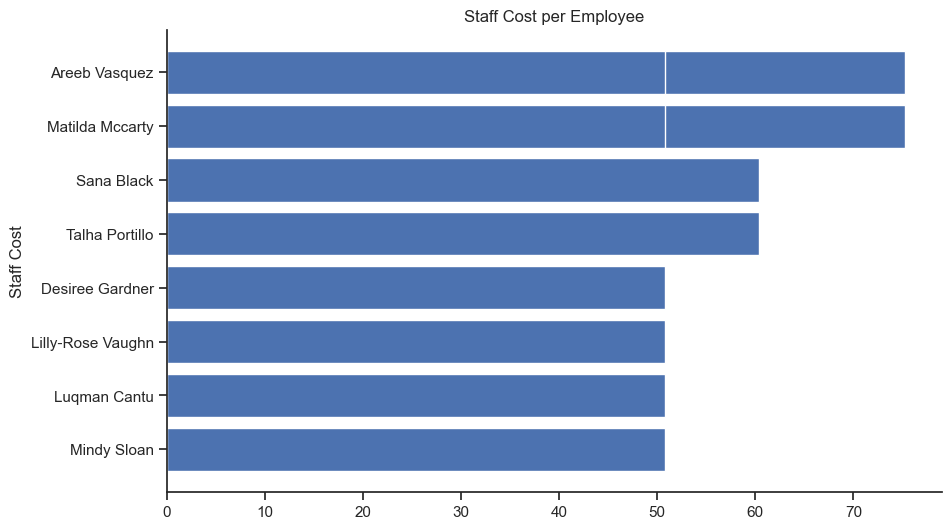

In [88]:
data = pd.read_sql_query("""
SELECT 
    r.date,
    s.first_name,
    s.last_name,
    s.hourly_rate,
    sh.start_time,
    sh.end_time,
    EXTRACT(EPOCH FROM (sh.end_time - sh.start_time)) / 3600 AS hours_in_shift,
    (EXTRACT(EPOCH FROM (sh.end_time - sh.start_time)) / 3600) * s.hourly_rate AS staff_cost
FROM
    rotations r
LEFT JOIN
    staff s ON r.staff_id = s.staff_id
LEFT JOIN
    shifts sh ON r.shift_id = sh.shift_id
LIMIT 10;
""", conn)
employee = (data["first_name"]) + " " +(data["last_name"])
data = data.sort_values(by="staff_cost", ascending=False)

plt.figure(figsize=(10,6))
ax=plt.barh(employee, data["staff_cost"])
plt.xlabel("")
plt.ylabel("Staff Cost")
plt.gca().invert_yaxis()
sns.despine()
plt.title("Staff Cost per Employee")
plt.show()